# 06 - SHAP and cost-sensitive evaluation

Notebook này chỉ dùng artifact XGBoost được huấn luyện trên split `v2_64_16_20`. Threshold được chọn trên validation và chỉ áp dụng một lần trên test.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
SPLIT_VERSION = 'v2_64_16_20'
ARTIFACT_VERSION = 'v2_64_16_20_val_split'
processed_path = DATA_DIR / 'processed_split.pkl'
provenance_path = RESULTS_DIR / f'xgb_provenance_{ARTIFACT_VERSION}.json'
xgb_model_path = RESULTS_DIR / f'xgb_smote_model_{ARTIFACT_VERSION}.pkl'
if not processed_path.exists() or not provenance_path.exists() or not xgb_model_path.exists():
    raise FileNotFoundError('Run 03_prepare_dataset.ipynb and 05_extension_smote_xgboost.ipynb first.')

data = joblib.load(processed_path)
split_metadata = data['split_metadata']
if split_metadata['split_version'] != SPLIT_VERSION:
    raise ValueError(f"Expected {SPLIT_VERSION}; found {split_metadata['split_version']}")

with open(provenance_path, encoding='utf-8') as file:
    xgb_provenance = json.load(file)
if xgb_provenance['artifact_version'] != ARTIFACT_VERSION:
    raise ValueError('XGBoost artifact provenance does not match the requested version.')

X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
xgb_smote_model = joblib.load(xgb_model_path)
baseline_models = joblib.load(RESULTS_DIR / 'baseline_models.pkl')
decision_tree_model = baseline_models['decision_tree']

print(f"Loaded XGBoost artifact: {xgb_model_path}")
print(f"Split: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
print(f"SMOTE fit split: {xgb_provenance['smote_fit_split']}")


Loaded XGBoost artifact: d:\GitHub\fraud-detection-thesis\results\xgb_smote_model_v2_64_16_20_val_split.pkl
Split: train=(4072076, 15), val=(1018020, 15), test=(1272524, 15)
SMOTE fit split: train_only


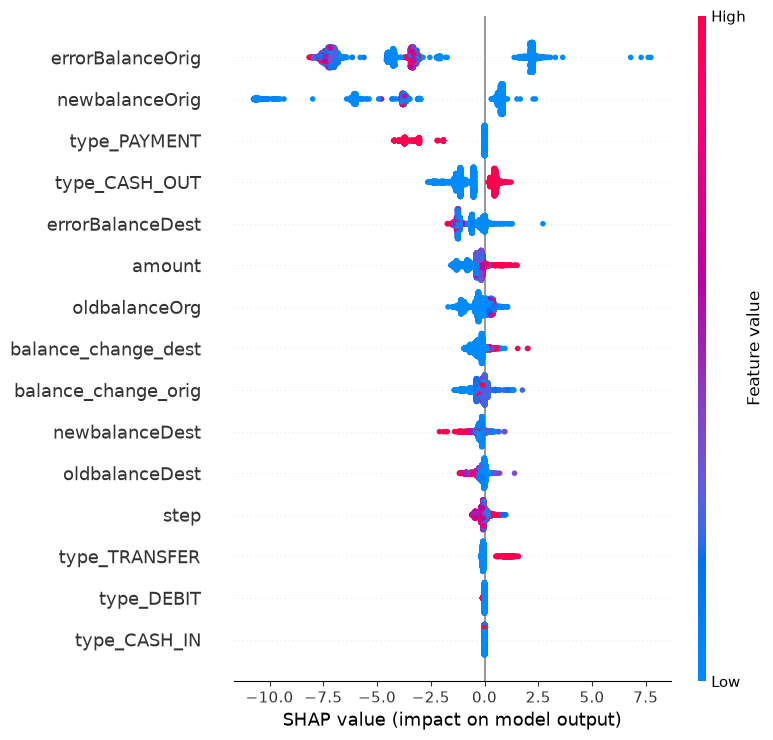

            feature  mean_abs_shap  rank      artifact_version
   errorBalanceOrig       4.795594     1 v2_64_16_20_val_split
     newbalanceOrig       2.716739     2 v2_64_16_20_val_split
       type_PAYMENT       1.136287     3 v2_64_16_20_val_split
      type_CASH_OUT       0.884794     4 v2_64_16_20_val_split
   errorBalanceDest       0.656907     5 v2_64_16_20_val_split
             amount       0.446661     6 v2_64_16_20_val_split
      oldbalanceOrg       0.373197     7 v2_64_16_20_val_split
balance_change_dest       0.297767     8 v2_64_16_20_val_split
balance_change_orig       0.264444     9 v2_64_16_20_val_split
     newbalanceDest       0.224565    10 v2_64_16_20_val_split


In [2]:
explainer = shap.TreeExplainer(xgb_smote_model)
X_test_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
shap_values = np.asarray(explainer.shap_values(X_test_sample))
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]

feature_ranking = (
    pd.DataFrame({
        'feature': X_test_sample.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
feature_ranking['rank'] = np.arange(1, len(feature_ranking) + 1)
feature_ranking['artifact_version'] = ARTIFACT_VERSION
feature_ranking.to_csv(RESULTS_DIR / f'shap_feature_ranking_{ARTIFACT_VERSION}.csv', index=False)

shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'shap_summary_plot_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()
print(feature_ranking.head(10).to_string(index=False))


True positive index: 6202693
False negative index: 543928


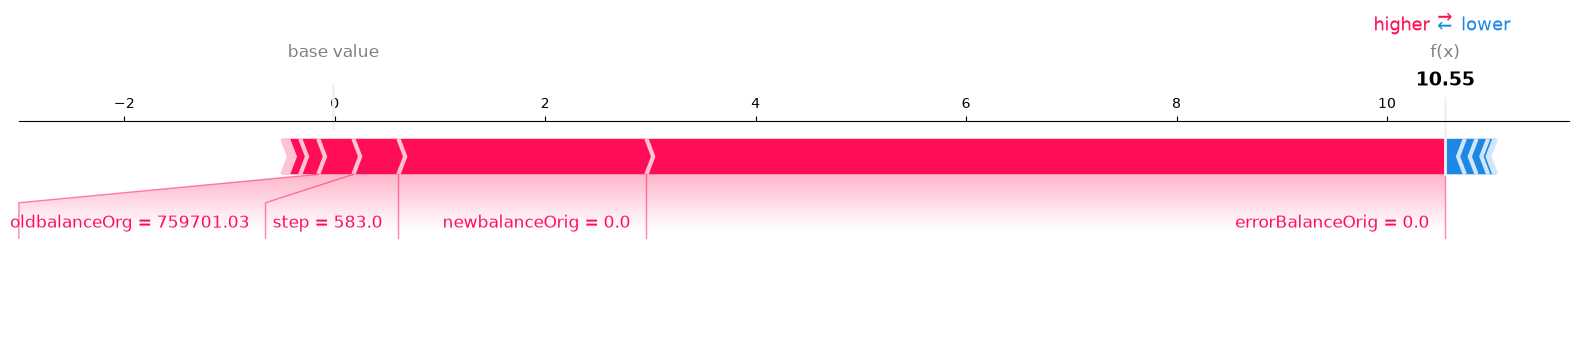

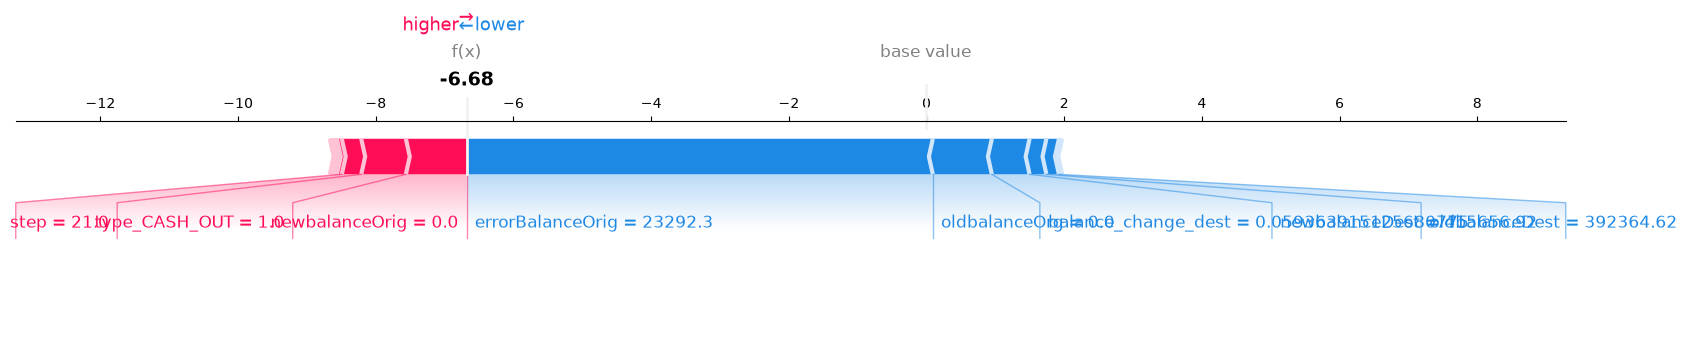

In [3]:
def expected_value_for_binary(explainer):
    value = explainer.expected_value
    if isinstance(value, (list, tuple, np.ndarray)):
        return np.asarray(value).ravel()[-1]
    return value

def save_force_plot(index, filename):
    if index is None:
        return
    if index in X_test_sample.index:
        position = X_test_sample.index.get_loc(index)
        values = shap_values[position]
        row = X_test_sample.loc[index]
    else:
        row = X_test.loc[[index]]
        values = np.asarray(explainer.shap_values(row))
        if values.ndim == 3:
            values = values[:, :, -1]
        values = values[0]
        row = row.iloc[0]
    shap.force_plot(expected_value_for_binary(explainer), values, row, matplotlib=True, show=False)
    plt.savefig(RESULTS_DIR / f'{filename}_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
    plt.show()

test_scores = xgb_smote_model.predict_proba(X_test)[:, 1]
test_predictions = (test_scores >= 0.5).astype(int)
fraud_indices = y_test[y_test == 1].index
fraud_predictions = test_predictions[y_test.index.get_indexer(fraud_indices)]
tp_candidates = fraud_indices[fraud_predictions == 1]
fn_candidates = fraud_indices[fraud_predictions == 0]
tp_index = tp_candidates[0] if len(tp_candidates) else None
fn_index = fn_candidates[0] if len(fn_candidates) else None
print(f'True positive index: {tp_index}')
print(f'False negative index: {fn_index}')
save_force_plot(tp_index, 'shap_force_plot_TP')
save_force_plot(fn_index, 'shap_force_plot_FN')


In [4]:
FP_COST = 1
FN_COST = 50
thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)

def cost_row(model, X_eval, y_true, model_name, threshold, split_name):
    score = model.predict_proba(X_eval)[:, 1]
    prediction = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    total_cost = int(fp * FP_COST + fn * FN_COST)
    return {
        'model': model_name, 'threshold': float(threshold), 'evaluation_split': split_name,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'fp_cost': FP_COST, 'fn_cost': FN_COST, 'total_cost': total_cost,
        'cost_per_transaction': total_cost / len(y_true),
        'missed_fraud_rate': fn / (fn + tp) if fn + tp else 0.0,
        'investigation_rate': (fp + tp) / len(y_true),
        'artifact_version': ARTIFACT_VERSION,
    }

models = {'Decision Tree': decision_tree_model, 'XGBoost + SMOTE': xgb_smote_model}
validation_rows = [
    cost_row(model, X_val, y_val, name, threshold, 'validation')
    for threshold in thresholds
    for name, model in models.items()
]
validation_sweep = pd.DataFrame(validation_rows)
validation_sweep.to_csv(RESULTS_DIR / f'cost_sensitive_validation_sweep_{ARTIFACT_VERSION}.csv', index=False)

selected_thresholds = (
    validation_sweep
    .sort_values(['model', 'total_cost', 'investigation_rate', 'threshold'], ascending=[True, True, True, False])
    .drop_duplicates('model')
    .assign(threshold_selection_split='validation', selection_reason='minimum validation total cost; tie-break lower investigation rate then higher threshold')
    .reset_index(drop=True)
)
selected_thresholds.to_csv(RESULTS_DIR / f'cost_sensitive_selected_thresholds_{ARTIFACT_VERSION}.csv', index=False)
print('Selected thresholds from validation:')
print(selected_thresholds[['model', 'threshold', 'total_cost', 'threshold_selection_split', 'selection_reason']].to_string(index=False))


Selected thresholds from validation:
          model  threshold  total_cost threshold_selection_split                                                                        selection_reason
  Decision Tree       0.95         158                validation minimum validation total cost; tie-break lower investigation rate then higher threshold
XGBoost + SMOTE       0.95         153                validation minimum validation total cost; tie-break lower investigation rate then higher threshold


In [5]:
final_test_rows = [
    cost_row(models[row['model']], X_test, y_test, row['model'], row['threshold'], 'test')
    for _, row in selected_thresholds.iterrows()
]
final_test = pd.DataFrame(final_test_rows)
final_test['threshold_source'] = 'validation'
final_test['threshold_selection_split'] = 'validation'
final_test['final_evaluation_split'] = 'test'
final_test.to_csv(RESULTS_DIR / f'cost_sensitive_test_final_{ARTIFACT_VERSION}.csv', index=False)

with open(RESULTS_DIR / f'cost_sensitive_provenance_{ARTIFACT_VERSION}.json', 'w', encoding='utf-8') as file:
    json.dump({
        'artifact_version': ARTIFACT_VERSION, 'split_version': SPLIT_VERSION,
        'cost_matrix': {'false_positive': FP_COST, 'false_negative': FN_COST},
        'validation_sweep_artifact': f'cost_sensitive_validation_sweep_{ARTIFACT_VERSION}.csv',
        'selected_thresholds_artifact': f'cost_sensitive_selected_thresholds_{ARTIFACT_VERSION}.csv',
        'final_test_artifact': f'cost_sensitive_test_final_{ARTIFACT_VERSION}.csv',
        'test_used_for_threshold_selection': False,
    }, file, indent=2)

print('Official final test results:')
print(final_test[['model', 'threshold', 'tn', 'fp', 'fn', 'tp', 'total_cost', 'cost_per_transaction', 'threshold_source', 'final_evaluation_split']].to_string(index=False))


Official final test results:
          model  threshold      tn  fp  fn   tp  total_cost  cost_per_transaction threshold_source final_evaluation_split
  Decision Tree       0.95 1270875   6   4 1639         206              0.000162       validation                   test
XGBoost + SMOTE       0.95 1270877   4   4 1639         204              0.000160       validation                   test
